In [1]:
# Raw Data Loading
import pandas as pd

red_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial' +\
                        '/master/dataset/winequality-red.csv'
white_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial' +\
                        '/master/dataset/winequality-white.csv'

red_wine = pd.read_csv(red_url, sep = ';')
white_wine = pd.read_csv(white_url, sep = ";")

wine = pd.concat([red_wine, white_wine])
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
# quality 5를 기준으로 taste 컬럼 추가
wine['taste'] = [1 if grade > 5 else 0 for grade in wine['quality']]
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,taste
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [3]:
# Data Split
from sklearn.model_selection import train_test_split

x = wine.drop(['taste', 'quality'], axis=1)
y = wine['taste']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=13)

In [4]:
# Model
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth=2, random_state=13)
dtc.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=13)

In [ ]:
# Evaluate
# precision: 모델이 참으로 예측한 것중 맞춘 비율
# recall: 실제 참인 것 중 모델이 맞춘 비율
# f1: precision과 recall의 조화평균
# roc_auc_score: roc 곡선의 면적 (1에 가까울수록 좋은 성능)
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

pred_test = dtc.predict(x_test)

print(f'accuracy_score: {accuracy_score(y_test, pred_test)}')
print(f'recall_score: {recall_score(y_test, pred_test)}')
print(f'precision_score: {precision_score(y_test, pred_test)}')
print(f'roc_auc_score: {roc_auc_score(y_test, pred_test)}')
print(f'f1_score: {f1_score(y_test, pred_test)}')

accuracy_score: 0.7276923076923076
recall_score: 0.7849331713244229
precision_score: 0.7849331713244229
roc_auc_score: 0.706931994467243
f1_score: 0.7849331713244229


In [6]:
dtc.predict_proba(x_test)

array([[0.06557377, 0.93442623],
       [0.63850486, 0.36149514],
       [0.63850486, 0.36149514],
       ...,
       [0.27900147, 0.72099853],
       [0.63850486, 0.36149514],
       [0.27900147, 0.72099853]])

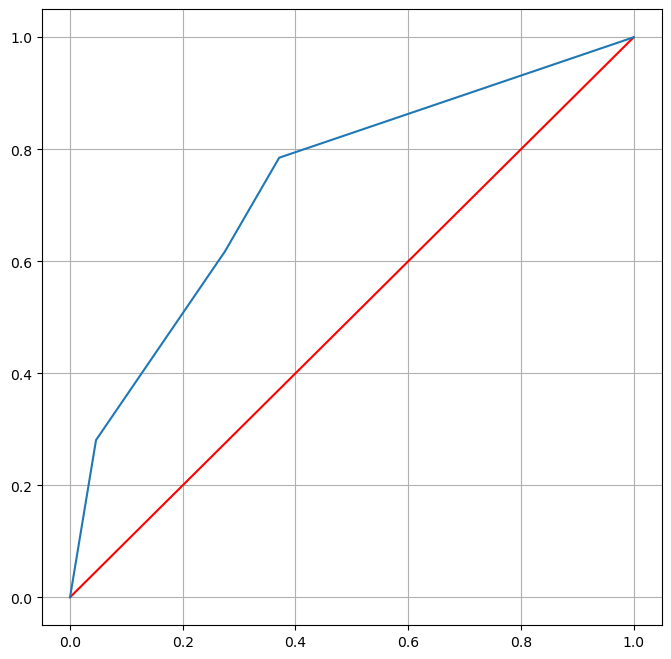

In [ ]:
# ROC 곡선 그리기
# ROC 곡선 아래 면적이 roc_auc_score (0.5 ~ 1.0)
# 이때 0.5(y = x)에 가까울수록 안좋은 성능을,
# 0.1(정사각형)에 가까울수록 좋은 성능을 의미
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# label 1에 대해서만
pred_proba = dtc.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, pred_proba)

plt.figure(figsize=(8, 8))

plt.plot([0, 1], [0, 1], 'r')
plt.plot(fpr, tpr)

plt.grid()
plt.show()